<a href="https://colab.research.google.com/github/nikhilfendre/CSL701-CS15-Machine-Learning-Lab/blob/main/Experiments/CS15_ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Nikhil Prasad Fendre
Roll No: CS15
Batch : CS1

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [4]:
# ============================================
# Task 1: Environment Setup and Dataset Loading
# ============================================

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# --------------------------------------------
# Load the dataset
# --------------------------------------------

file_path = "diabetes.csv"

df = pd.read_csv(file_path)

# --------------------------------------------
# Assign column names if dataset has no headers
# --------------------------------------------

expected_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Check whether the dataset already has the correct columns
if not all(column in df.columns for column in expected_columns):
    # If there are 9 columns, assign the standard Pima column names
    if df.shape[1] == 9:
        df.columns = expected_columns

# --------------------------------------------
# Display first five records
# --------------------------------------------

print("First Five Records:")
print(df.head())

# --------------------------------------------
# Display dataset shape
# --------------------------------------------

print("\nDataset Shape:")
print(df.shape)

# --------------------------------------------
# Display data types
# --------------------------------------------

print("\nData Types of All Features:")
print(df.dtypes)

# --------------------------------------------
# Display descriptive statistics
# --------------------------------------------

print("\nDescriptive Statistics:")
print(df.describe())

First Five Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Data Types of All Features:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedig

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Distribution
-------------------
Non-Diabetic (Outcome = 0): 500
Diabetic (Outcome = 1): 268

Class Percentages
-----------------
Non-Diabetic: 65.10%
Diabetic: 34.90%


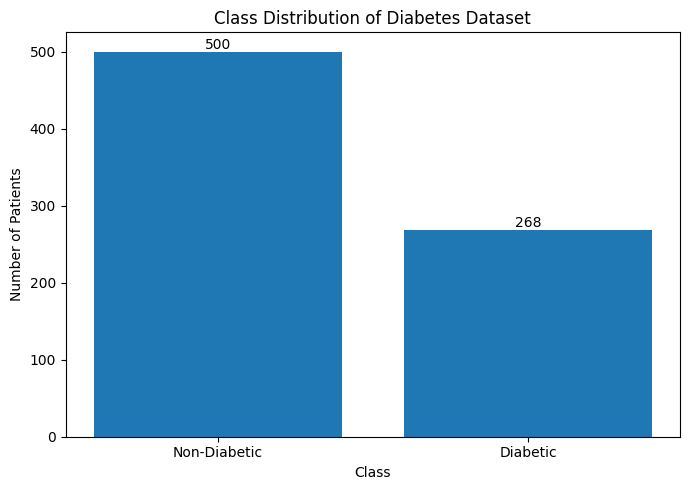

In [5]:
# ============================================
# Task 2: Exploratory Data Analysis (EDA)
# ============================================

# Calculate absolute counts
non_diabetic = (df["Outcome"] == 0).sum()
diabetic = (df["Outcome"] == 1).sum()

# Calculate total number of cases
total = len(df)

# Calculate percentages
non_diabetic_percentage = (non_diabetic / total) * 100
diabetic_percentage = (diabetic / total) * 100

# Display results
print("Class Distribution")
print("-------------------")

print(f"Non-Diabetic (Outcome = 0): {non_diabetic}")
print(f"Diabetic (Outcome = 1): {diabetic}")

print("\nClass Percentages")
print("-----------------")

print(f"Non-Diabetic: {non_diabetic_percentage:.2f}%")
print(f"Diabetic: {diabetic_percentage:.2f}%")

# --------------------------------------------
# Bar Chart for Class Balance
# --------------------------------------------

classes = ["Non-Diabetic", "Diabetic"]
counts = [non_diabetic, diabetic]

plt.figure(figsize=(7, 5))

bars = plt.bar(classes, counts)

plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("Class Distribution of Diabetes Dataset")

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

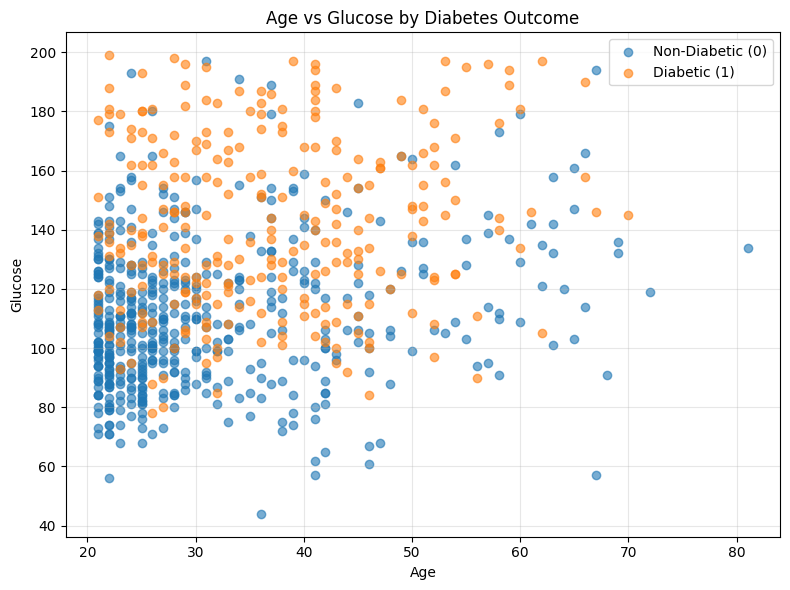

In [6]:
# --------------------------------------------
# Scatter Plot: Age vs Glucose
# --------------------------------------------

plt.figure(figsize=(8, 6))

# Non-diabetic patients
plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    label="Non-Diabetic (0)",
    alpha=0.6
)

# Diabetic patients
plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    label="Diabetic (1)",
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose by Diabetes Outcome")
plt.legend()

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#A simple linear decision boundary has the form:

$$ w_1x_1+w_2x_2+b=0 $$

For this dataset, using only Age and Glucose, a single straight line cannot perfectly separate diabetic and non-diabetic patients because the two classes overlap.

For example, some patients with relatively high glucose may still be non-diabetic, while some patients with similar ages and glucose values may be diabetic. Diabetes is also influenced by other features such as BMI, pregnancies, blood pressure, insulin, and diabetes pedigree function.

Therefore, the relationship between the features and diabetes outcome is not purely linear. A Decision Tree can create nonlinear decision boundaries, while Bagging can combine many such trees to reduce variance and improve generalization.

Conclusion for Task 2

The EDA shows that the dataset contains 768 patients, with 500 non-diabetic and 268 diabetic cases. The class distribution is imbalanced, with approximately 65.10% non-diabetic and 34.90% diabetic patients. The Age vs Glucose scatter plot shows some separation between the classes, particularly at higher glucose levels, but there is substantial overlap. Hence, a simple linear decision boundary is insufficient to clearly classify all patients, motivating the use of nonlinear classifiers such as Decision Trees and ensemble methods such as Bagging.

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [7]:
# ============================================
# Task 3: Preprocessing and Handling Missing Values
# ============================================

import numpy as np
import pandas as pd

# Features where 0 is physically impossible
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# --------------------------------------------
# Step 1: Check invalid zero values
# --------------------------------------------

print("Number of invalid zero values before replacement:")
print((df[invalid_features] == 0).sum())

# --------------------------------------------
# Step 2: Replace 0 with NaN
# --------------------------------------------

df[invalid_features] = df[invalid_features].replace(0, np.nan)

print("\nMissing values after replacing 0 with NaN:")
print(df[invalid_features].isnull().sum())

# --------------------------------------------
# Step 3: Impute missing values using median
# --------------------------------------------

for column in invalid_features:
    df[column] = df[column].fillna(df[column].median())

# --------------------------------------------
# Verify that there are no missing values
# --------------------------------------------

print("\nMissing values after median imputation:")
print(df[invalid_features].isnull().sum())

# --------------------------------------------
# Display cleaned dataset
# --------------------------------------------

print("\nFirst five records after preprocessing:")
print(df.head())

# --------------------------------------------
# Check final dataset shape
# --------------------------------------------

print("\nFinal Dataset Shape:")
print(df.shape)

Number of invalid zero values before replacement:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after replacing 0 with NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

First five records after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [8]:
# ============================================
# Task 4: Stratified Train-Test Splitting
# ============================================

from sklearn.model_selection import train_test_split

# --------------------------------------------
# Step 1: Separate Features (X) and Target (y)
# --------------------------------------------

# First 8 columns are features
X = df.iloc[:, :8]

# 9th column is the target
y = df.iloc[:, 8]

# Display shapes
print("Feature Matrix (X) Shape:", X.shape)
print("Target Vector (y) Shape:", y.shape)

# --------------------------------------------
# Step 2: Stratified Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# Step 3: Display dataset sizes
# --------------------------------------------

print("\nTraining Data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting Data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# --------------------------------------------
# Step 4: Check class distribution
# --------------------------------------------

print("\nOriginal Class Distribution:")
print(y.value_counts())

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

# --------------------------------------------
# Step 5: Check class percentages
# --------------------------------------------

print("\nOriginal Class Percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTraining Class Percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Class Percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Feature Matrix (X) Shape: (768, 8)
Target Vector (y) Shape: (768,)

Training Data:
X_train shape: (614, 8)
y_train shape: (614,)

Testing Data:
X_test shape: (154, 8)
y_test shape: (154,)

Original Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Training Class Distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing Class Distribution:
Outcome
0    100
1     54
Name: count, dtype: int64

Original Class Percentages:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

Training Class Percentages:
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64

Testing Class Percentages:
Outcome
0    64.94
1    35.06
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [9]:
# ============================================
# Task 5: Custom Bootstrap Sampling Function
# ============================================

import numpy as np

def get_bootstrap_sample(X, y):
    """
    Generate a bootstrap sample from the training data.

    Sampling is performed with replacement.
    The bootstrap sample has the same number of
    samples as the original training dataset.
    """

    # Number of training samples
    N = len(X)

    # Randomly select row indices with replacement
    bootstrap_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[bootstrap_indices].copy()
    y_bootstrap = y.iloc[bootstrap_indices].copy()

    return X_bootstrap, y_bootstrap, bootstrap_indices


# --------------------------------------------
# Test the bootstrap function
# --------------------------------------------

X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# --------------------------------------------
# Display sizes
# --------------------------------------------

print("Original Training Set Size:", len(X_train))
print("Bootstrap Sample Size:", len(X_bootstrap))

print("\nBootstrap Feature Matrix Shape:")
print(X_bootstrap.shape)

print("\nBootstrap Target Vector Shape:")
print(y_bootstrap.shape)

# --------------------------------------------
# Display selected indices
# --------------------------------------------

print("\nFirst 30 Bootstrap Indices:")
print(bootstrap_indices[:30])

# --------------------------------------------
# Find duplicated indices
# --------------------------------------------

unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\nDuplicated Original Row Indices:")
print(duplicated_indices)

print("\nNumber of Duplicated Indices:",
      len(duplicated_indices))

# --------------------------------------------
# Find OOB (Out-of-Bag) indices
# --------------------------------------------

all_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("\nOut-of-Bag (OOB) Indices:")
print(oob_indices)

print("\nNumber of OOB Samples:",
      len(oob_indices))

Original Training Set Size: 614
Bootstrap Sample Size: 614

Bootstrap Feature Matrix Shape:
(614, 8)

Bootstrap Target Vector Shape:
(614,)

First 30 Bootstrap Indices:
[508 357 194 248 288 275 113 356 191 368 419 376 412 127 603 261 348 312
   1 381 240 202  64  64 167 488 484 446  76 164]

Duplicated Original Row Indices:
[  1   3   6  17  21  26  35  36  44  48  49  53  56  58  63  64  74  75
  76  77  88  90  96 101 108 113 115 121 123 129 131 133 140 150 153 154
 156 160 163 164 166 167 169 172 173 178 179 186 187 193 194 195 199 200
 201 202 206 209 210 214 220 223 225 228 235 242 243 244 247 251 258 260
 262 269 272 273 274 275 276 283 287 288 291 298 301 308 311 312 318 320
 332 335 336 342 344 345 346 347 349 356 357 359 364 368 375 380 386 390
 407 412 419 430 438 439 450 457 460 476 487 502 505 508 511 513 519 522
 527 529 530 532 534 537 538 539 543 545 546 550 552 558 559 561 563 564
 566 574 585 588 593 594 598 603 604 612]

Number of Duplicated Indices: 154

Out-of-Bag (

#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [10]:
# ============================================
# Task 6: Growing the Ensemble of Base Classifiers
# ============================================

from sklearn.tree import DecisionTreeClassifier

# Number of bootstrap iterations / base learners
B = 50

# Empty list to store trained decision trees
ensemble = []

# --------------------------------------------
# Train B Decision Trees
# --------------------------------------------

for b in range(B):

    # Generate a bootstrap sample
    X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model on the bootstrap sample
    model.fit(X_bootstrap, y_bootstrap)

    # Add trained model to the ensemble
    ensemble.append(model)

    print(f"Decision Tree {b + 1} trained successfully.")

# --------------------------------------------
# Verify ensemble size
# --------------------------------------------

print("\n===================================")
print("Ensemble Training Completed")
print("===================================")

print("Number of Decision Trees:", len(ensemble))
print("Expected Number of Trees:", B)

Decision Tree 1 trained successfully.
Decision Tree 2 trained successfully.
Decision Tree 3 trained successfully.
Decision Tree 4 trained successfully.
Decision Tree 5 trained successfully.
Decision Tree 6 trained successfully.
Decision Tree 7 trained successfully.
Decision Tree 8 trained successfully.
Decision Tree 9 trained successfully.
Decision Tree 10 trained successfully.
Decision Tree 11 trained successfully.
Decision Tree 12 trained successfully.
Decision Tree 13 trained successfully.
Decision Tree 14 trained successfully.
Decision Tree 15 trained successfully.
Decision Tree 16 trained successfully.
Decision Tree 17 trained successfully.
Decision Tree 18 trained successfully.
Decision Tree 19 trained successfully.
Decision Tree 20 trained successfully.
Decision Tree 21 trained successfully.
Decision Tree 22 trained successfully.
Decision Tree 23 trained successfully.
Decision Tree 24 trained successfully.
Decision Tree 25 trained successfully.
Decision Tree 26 trained successfu

#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [11]:
# ============================================
# Task 7: Custom Majority Voting
# ============================================

import numpy as np

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting.

    Parameters:
        ensemble : list
            List of trained Decision Tree classifiers.

        X_test : DataFrame
            Test feature data.

    Returns:
        final_predictions : NumPy array
            Majority-voted predictions (0 or 1).
    """

    # Store predictions from every decision tree
    all_predictions = []

    # ----------------------------------------
    # Get predictions from every tree
    # ----------------------------------------

    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert list to NumPy array
    # Shape = (number of trees, number of test samples)
    all_predictions = np.array(all_predictions)

    # ----------------------------------------
    # Majority Voting
    # ----------------------------------------

    # Count votes for class 0
    votes_class_0 = np.sum(all_predictions == 0, axis=0)

    # Count votes for class 1
    votes_class_1 = np.sum(all_predictions == 1, axis=0)

    # Select the class with the highest number of votes
    final_predictions = np.where(
        votes_class_1 > votes_class_0,
        1,
        0
    )

    return final_predictions


# ============================================
# Generate Bagging Predictions
# ============================================

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

# --------------------------------------------
# Display predictions
# --------------------------------------------

print("Bagging Predictions:")
print(y_pred_bagging)

# --------------------------------------------
# Verify prediction values
# --------------------------------------------

print("\nUnique Predicted Classes:")
print(np.unique(y_pred_bagging))

# Verify that predictions are only 0 or 1
assert np.all(np.isin(y_pred_bagging, [0, 1]))

print("\nMajority voting completed successfully!")
print("Number of test predictions:", len(y_pred_bagging))

Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]

Unique Predicted Classes:
[0 1]

Majority voting completed successfully!
Number of test predictions: 154


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

CONFUSION MATRICES

Single Decision Tree:
[[87 13]
 [16 38]]

Custom Bagging:
[[93  7]
 [ 8 46]]

PERFORMANCE COMPARISON

Single Decision Tree
--------------------
Accuracy  : 0.8117
Precision : 0.7451
Recall    : 0.7037
F1-Score  : 0.7238

Custom Bagging
--------------------
Accuracy  : 0.9026
Precision : 0.8679
Recall    : 0.8519
F1-Score  : 0.8598


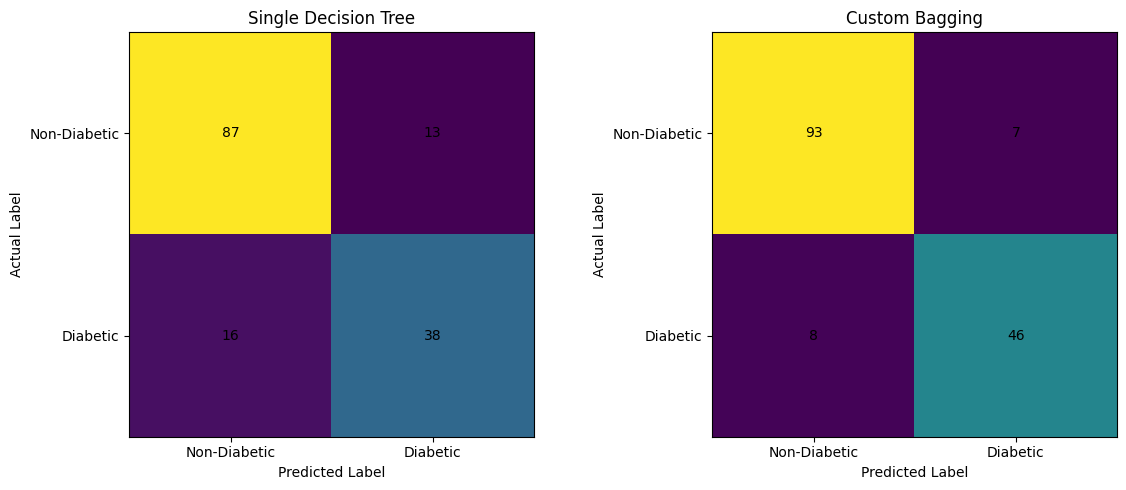

In [12]:
# ============================================
# Task 8: Single Classifier vs Bagging
# ============================================

import matplotlib.pyplot as plt
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------
# 1. Train Single Fully Grown Decision Tree
# --------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

# --------------------------------------------
# 2. Predictions
# --------------------------------------------

# Single Decision Tree prediction
y_pred_single = single_tree.predict(X_test)

# Custom Bagging prediction
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

# --------------------------------------------
# 3. CONFUSION MATRICES
# --------------------------------------------

cm_single = confusion_matrix(
    y_test,
    y_pred_single
)

cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("============================================")
print("CONFUSION MATRICES")
print("============================================")

print("\nSingle Decision Tree:")
print(cm_single)

print("\nCustom Bagging:")
print(cm_bagging)

# --------------------------------------------
# 4. Performance Metrics
# --------------------------------------------

# Single Decision Tree
accuracy_single = accuracy_score(y_test, y_pred_single)
precision_single = precision_score(y_test, y_pred_single)
recall_single = recall_score(y_test, y_pred_single)
f1_single = f1_score(y_test, y_pred_single)

# Bagging
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)

# --------------------------------------------
# 5. Print Metrics
# --------------------------------------------

print("\n============================================")
print("PERFORMANCE COMPARISON")
print("============================================")

print("\nSingle Decision Tree")
print("--------------------")
print(f"Accuracy  : {accuracy_single:.4f}")
print(f"Precision : {precision_single:.4f}")
print(f"Recall    : {recall_single:.4f}")
print(f"F1-Score  : {f1_single:.4f}")

print("\nCustom Bagging")
print("--------------------")
print(f"Accuracy  : {accuracy_bagging:.4f}")
print(f"Precision : {precision_bagging:.4f}")
print(f"Recall    : {recall_bagging:.4f}")
print(f"F1-Score  : {f1_bagging:.4f}")


# ============================================
# 6. PLOT CONFUSION MATRICES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------------------------
# Single Decision Tree Confusion Matrix
# --------------------------------------------

axes[0].imshow(cm_single)

axes[0].set_title("Single Decision Tree")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])

axes[0].set_xticklabels([
    "Non-Diabetic",
    "Diabetic"
])

axes[0].set_yticklabels([
    "Non-Diabetic",
    "Diabetic"
])

# Add numbers inside matrix
for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            cm_single[i, j],
            ha="center",
            va="center"
        )


# --------------------------------------------
# Bagging Confusion Matrix
# --------------------------------------------

axes[1].imshow(cm_bagging)

axes[1].set_title("Custom Bagging")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

axes[1].set_xticklabels([
    "Non-Diabetic",
    "Diabetic"
])

axes[1].set_yticklabels([
    "Non-Diabetic",
    "Diabetic"
])

# Add numbers inside matrix
for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            cm_bagging[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

ROC-AUC Results
Single Decision Tree AUC : 0.7869
Bagging Ensemble AUC     : 0.9544

AUC Improvement          : 0.1675
Bagging produced a higher AUC than the single tree.


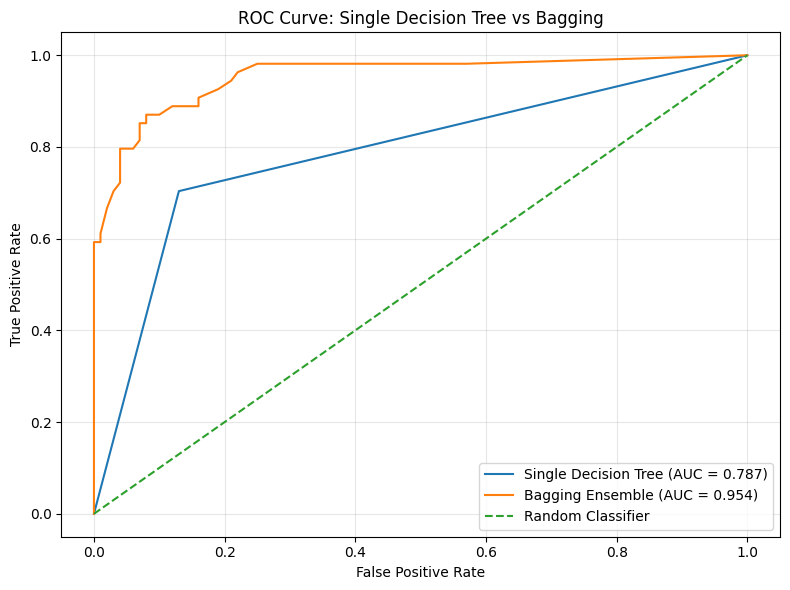

In [13]:
# ============================================
# Task 9: ROC-AUC Analysis
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# --------------------------------------------
# Step 1: Single Decision Tree Probabilities
# --------------------------------------------

# Probability of class 1 (Diabetic)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]

# --------------------------------------------
# Step 2: Bagging Probability Estimates
# --------------------------------------------

# Store probability predictions from all trees
all_probabilities = []

for model in ensemble:
    # Get probability of class 1
    probabilities = model.predict_proba(X_test)[:, 1]

    all_probabilities.append(probabilities)

# Convert to NumPy array
all_probabilities = np.array(all_probabilities)

# Average probabilities across all 50 trees
y_prob_bagging = np.mean(all_probabilities, axis=0)

# --------------------------------------------
# Step 3: Calculate ROC Curves
# --------------------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)

# --------------------------------------------
# Step 4: Calculate AUC
# --------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)

# --------------------------------------------
# Step 5: Print AUC Results
# --------------------------------------------

print("============================================")
print("ROC-AUC Results")
print("============================================")

print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Bagging Ensemble AUC     : {auc_bagging:.4f}")

# Calculate improvement
auc_improvement = auc_bagging - auc_single

print(f"\nAUC Improvement          : {auc_improvement:.4f}")

if auc_improvement > 0:
    print("Bagging produced a higher AUC than the single tree.")
elif auc_improvement < 0:
    print("Single Decision Tree produced a higher AUC.")
else:
    print("Both models produced the same AUC.")

# --------------------------------------------
# Step 6: Plot ROC Curves
# --------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Bagging Ensemble (AUC = {auc_bagging:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Decision Tree vs Bagging")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn BaggingClassifier trained successfully.

ACCURACY COMPARISON
Custom Bagging Accuracy     : 0.9026
Scikit-Learn Bagging Accuracy: 0.8831

Custom Bagging Accuracy     : 90.26%
Scikit-Learn Bagging Accuracy: 88.31%

CONFUSION MATRICES

Custom Bagging Confusion Matrix:
[[93  7]
 [ 8 46]]

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]


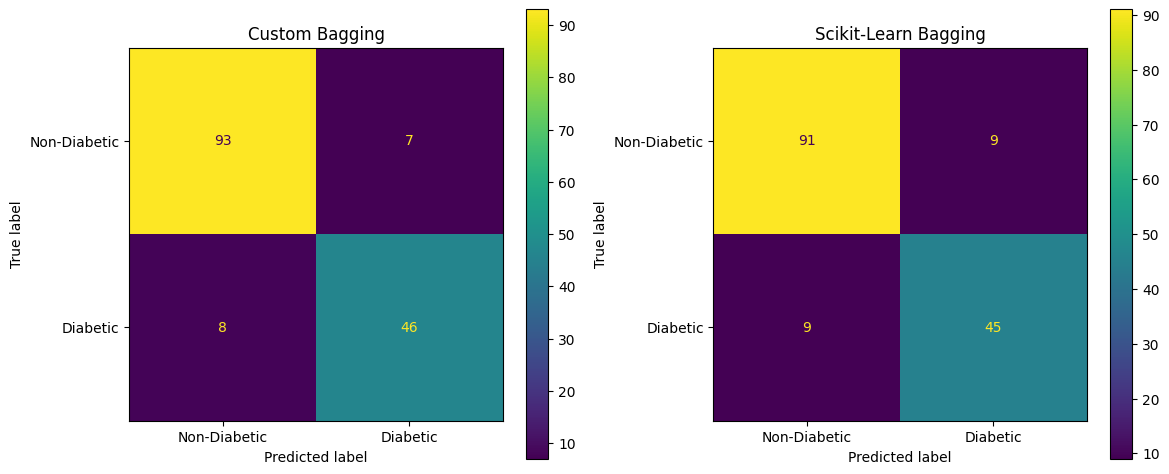


VALIDATION RESULT
Accuracy Difference: 0.0195
Percentage Difference: 1.95%


In [14]:
# ============================================
# Task 10: Validation against Scikit-Learn
# BaggingClassifier
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================
# 1. Create Scikit-Learn Bagging Classifier
# ============================================

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

# ============================================
# 2. Train the Scikit-Learn Bagging Model
# ============================================

sklearn_bagging.fit(X_train, y_train)

print("Scikit-Learn BaggingClassifier trained successfully.")

# ============================================
# 3. Make Predictions
# ============================================

y_pred_sklearn = sklearn_bagging.predict(X_test)

# Custom Bagging prediction from Task 7
y_pred_custom = custom_bagging_predict(
    ensemble,
    X_test
)

# ============================================
# 4. Calculate Accuracy
# ============================================

custom_accuracy = accuracy_score(
    y_test,
    y_pred_custom
)

sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

print("\n============================================")
print("ACCURACY COMPARISON")
print("============================================")

print(f"Custom Bagging Accuracy     : {custom_accuracy:.4f}")
print(f"Scikit-Learn Bagging Accuracy: {sklearn_accuracy:.4f}")

print(f"\nCustom Bagging Accuracy     : {custom_accuracy * 100:.2f}%")
print(f"Scikit-Learn Bagging Accuracy: {sklearn_accuracy * 100:.2f}%")

# ============================================
# 5. Calculate Confusion Matrices
# ============================================

cm_custom = confusion_matrix(
    y_test,
    y_pred_custom
)

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

print("\n============================================")
print("CONFUSION MATRICES")
print("============================================")

print("\nCustom Bagging Confusion Matrix:")
print(cm_custom)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)

# ============================================
# 6. Display Confusion Matrices Side-by-Side
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Custom Bagging
ConfusionMatrixDisplay(
    confusion_matrix=cm_custom,
    display_labels=["Non-Diabetic", "Diabetic"]
).plot(
    ax=axes[0],
    values_format="d"
)

axes[0].set_title("Custom Bagging")

# Scikit-Learn Bagging
ConfusionMatrixDisplay(
    confusion_matrix=cm_sklearn,
    display_labels=["Non-Diabetic", "Diabetic"]
).plot(
    ax=axes[1],
    values_format="d"
)

axes[1].set_title("Scikit-Learn Bagging")

plt.tight_layout()
plt.show()

# ============================================
# 7. Accuracy Difference
# ============================================

difference = abs(
    custom_accuracy - sklearn_accuracy
)

print("\n============================================")
print("VALIDATION RESULT")
print("============================================")

print(
    f"Accuracy Difference: {difference:.4f}"
)

print(
    f"Percentage Difference: {difference * 100:.2f}%"
)

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?